# UC00219 - Thermal Hotspot vs Tree Canopy Overlay

**Authored by:** Thien Khang Nguyen

**Duration:** 90 mins

**Level:** Intermediate

**Pre-requisite Skills:** Python, Data Cleaning, Data Visualisation, Geospatial Analysis, Raster and Vector Data Handling, Spatial Overlay

**Scenario**

As a student living in Melbourne, Khang has noticed that some parts of the city feel much hotter than others, especially during warm and dry days. When walking through different streets and open public spaces, he observed that areas with fewer trees often feel more exposed to heat, while areas with greater tree canopy tend to feel cooler and more comfortable. This made him interested in understanding whether these differences could be identified more clearly using spatial data.

Khang wants to have access to a system that can highlight Melbourne regions with high surface temperature and low tree canopy cover. By combining thermal imagery with tree canopy data, he hopes to identify urban areas that may be more vulnerable to heat and less protected by vegetation. This kind of analysis could help support discussions about urban heat resilience, canopy improvement, and greening priorities in future planning and environmental decision-making.


**Introduction**

Urban heat is a growing concern in cities, especially in areas with dense built surfaces, limited shade, and low vegetation cover. Surfaces such as roads, pavements, and rooftops can absorb and retain heat, causing some urban regions to become significantly warmer than others. Tree canopy plays an important role in reducing this effect by providing shade and contributing to urban cooling. Because of this, areas with high surface temperature and low canopy cover may be more vulnerable during hot weather conditions.

This use case focuses on identifying Melbourne regions where these two conditions may overlap. Instead of predicting future values over time, the project uses spatial analysis to compare a thermal image dataset with a tree canopy dataset. The thermal layer represents patterns of surface temperature, while the canopy layer represents the extent of urban tree cover. By analysing both datasets together, the project aims to highlight locations that may require greater attention in urban greening and heat resilience planning.

The datasets used in this project are the "Thermal Image 2012" dataset and the "Tree Canopies 2021 (Urban Forest)" dataset from the City of Melbourne website. Since the two datasets come from different years, the results should be interpreted as an exploratory spatial analysis rather than a same-time causal comparison. However, the project can still provide useful insight into broad spatial patterns of heat exposure and canopy distribution across Melbourne.


# 1. Importing The Libraries

In [1]:
# Libraries for this project.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio
import requests
import tempfile
import zipfile

from pathlib import Path
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from rasterio.plot import show
from rasterio.mask import mask
from shapely.geometry import box

print("Libraries imported successfully.")


Libraries imported successfully.


# 2. Loading the Tree Canopy Dataset

In [2]:
# Load tree canopy data from Melbourne Open Data API v2.1 (GeoJSON export).
canopy_api_url = (
    "https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets/"
    "tree-canopies-2021-urban-forest/exports/geojson?limit=-1"
)

response = requests.get(canopy_api_url, timeout=180)
response.raise_for_status()
canopy_geojson = response.json()

if "features" not in canopy_geojson or not canopy_geojson["features"]:
    raise ValueError("Canopy API returned no features.")

canopy_gdf = gpd.GeoDataFrame.from_features(canopy_geojson["features"])
if canopy_gdf.crs is None:
    canopy_gdf = canopy_gdf.set_crs(epsg=4326)

print("Tree canopy dataset loaded successfully from API 2.1.")
print("API URL:", canopy_api_url)


Tree canopy dataset loaded successfully from API 2.1.
API URL: https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets/tree-canopies-2021-urban-forest/exports/geojson?limit=-1


In [3]:
# Display the first 5 rows.
canopy_gdf.head()

,geometry,geo_point_2d
0,"MULTIPOLYGON (((144.9833 -37.82967, 144.98331 ...","{'lon': 144.98303001088595, 'lat': -37.8298681..."
1,"MULTIPOLYGON (((144.97145 -37.82983, 144.97146...","{'lon': 144.97144661356745, 'lat': -37.8298745..."
2,"MULTIPOLYGON (((144.98648 -37.83019, 144.98649...","{'lon': 144.98646678135142, 'lat': -37.8302139..."
3,"MULTIPOLYGON (((144.90117 -37.82874, 144.90118...","{'lon': 144.9011718210025, 'lat': -37.82874224..."
4,"MULTIPOLYGON (((144.96517 -37.82991, 144.96519...","{'lon': 144.96518349051888, 'lat': -37.8299209..."


In [4]:
# Check the shape of the dataset.
print("Dataset shape:", canopy_gdf.shape)

Dataset shape: (57980, 2)


In [5]:
# Display the column names.
print("Columns:")
print(canopy_gdf.columns)

Columns:
Index(['geometry', 'geo_point_2d'], dtype='str')


In [6]:
# Check the coordinate reference system.
print("CRS:", canopy_gdf.crs)

CRS: EPSG:4326


# 3. Inspecting the Geometry

In [7]:
# Check the geometry types.
print(canopy_gdf.geometry.geom_type.value_counts())

MultiPolygon    56979
Polygon          1001
Name: count, dtype: int64


# 4. Visualising the Tree Canopy Dataset

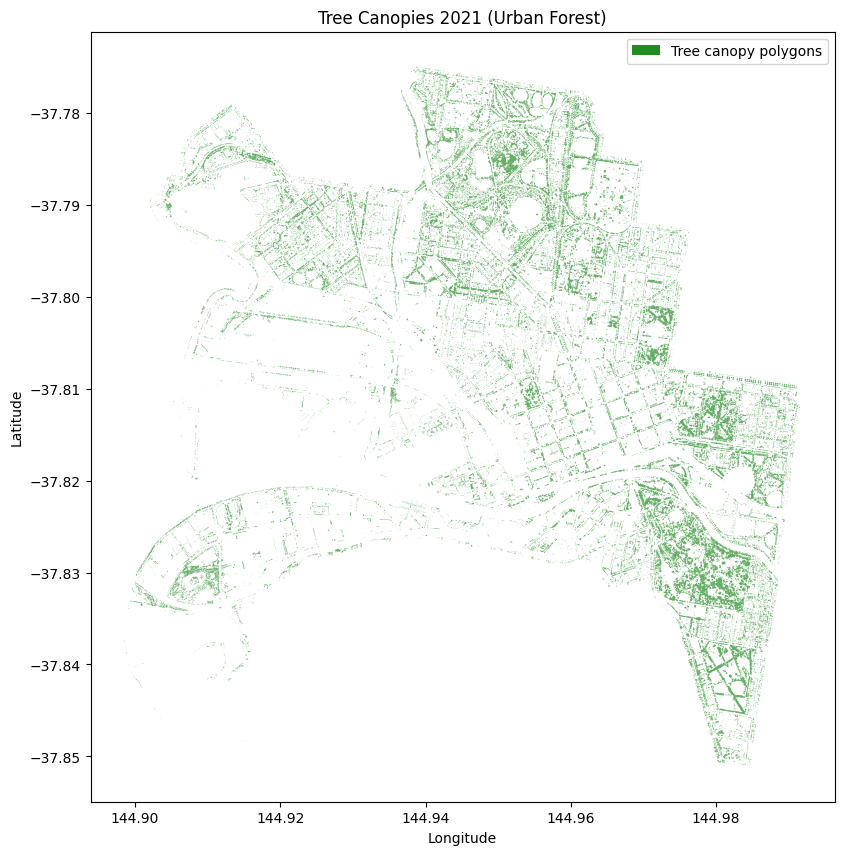

Interpretation: The canopy layer is concentrated within the Melbourne municipal footprint, with patchy coverage across suburbs.


In [8]:
# Plot the tree canopy dataset.
fig, ax = plt.subplots(figsize=(10, 10))
canopy_gdf.plot(ax=ax, color="forestgreen", edgecolor="none", alpha=0.7)
ax.set_title("Tree Canopies 2021 (Urban Forest)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(
    handles=[Patch(facecolor="forestgreen", edgecolor="none", label="Tree canopy polygons")],
    loc="upper right"
)
plt.show()

print("Interpretation: The canopy layer is concentrated within the Melbourne municipal footprint, with patchy coverage across suburbs.")


# 5. Checking Data Quality

In [9]:
# Check missing values.
print(canopy_gdf.isnull().sum())

geometry        0
geo_point_2d    0
dtype: int64


# 6. Checking the Spatial Extent

In [10]:
# Check the total bounds of the dataset.
print("Total bounds:", canopy_gdf.total_bounds)

Total bounds: [144.89855037 -37.85111574 144.99167222 -37.77500116]


# 7. Creating a Cleaner Visualisation

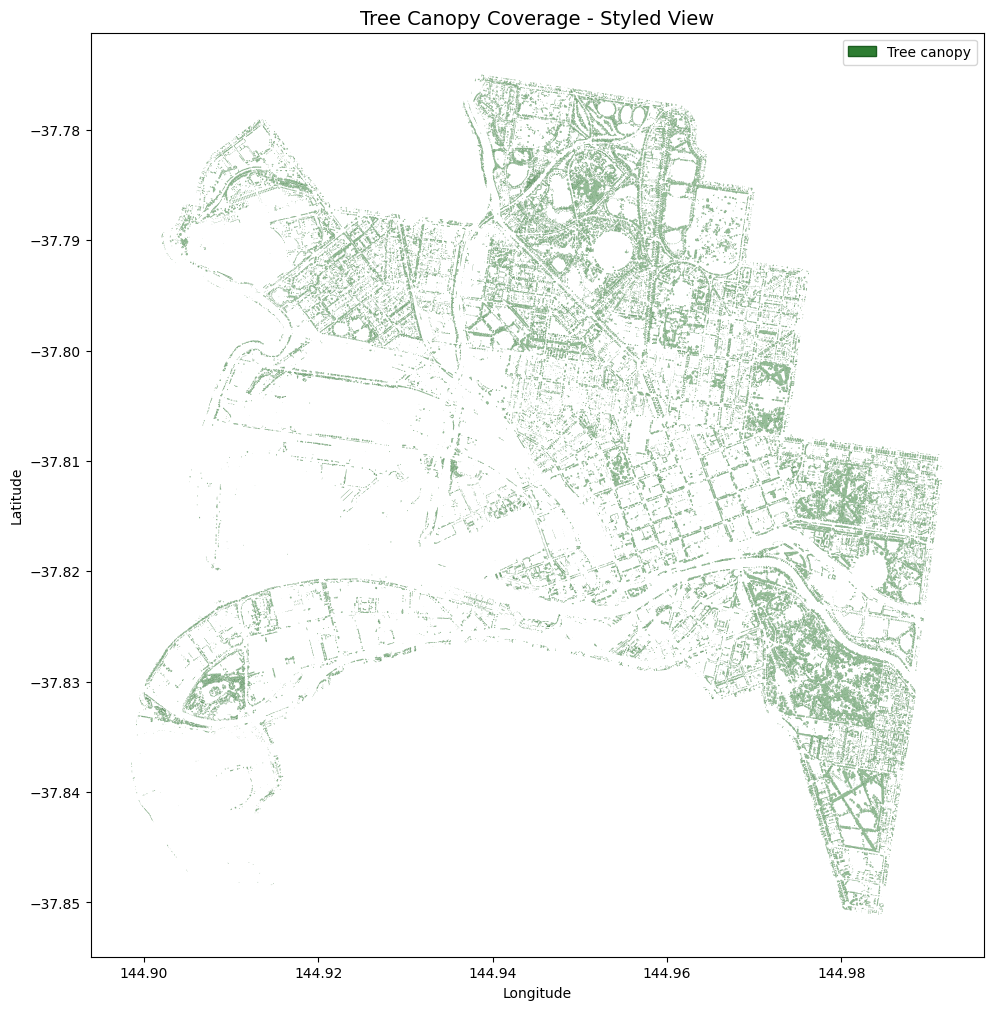

Interpretation: The styled view highlights canopy clusters and canopy gaps before thermal overlay.


In [11]:
# Plot the tree canopy dataset with improved styling.
fig, ax = plt.subplots(figsize=(12, 12))
canopy_gdf.plot(ax=ax, color="#2e7d32", edgecolor="#1b5e20", linewidth=0.1, alpha=0.5)
ax.set_title("Tree Canopy Coverage - Styled View", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(
    handles=[Patch(facecolor="#2e7d32", edgecolor="#1b5e20", label="Tree canopy")],
    loc="upper right"
)
plt.show()

print("Interpretation: The styled view highlights canopy clusters and canopy gaps before thermal overlay.")


# 8. Loading the Thermal Image Dataset

In [12]:
# Load thermal image data from Melbourne Open Data API v2.1 attachments.
thermal_meta_url = (
    "https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets/"
    "thermal-image-2012"
)

meta_response = requests.get(thermal_meta_url, timeout=120)
meta_response.raise_for_status()
thermal_meta = meta_response.json()

attachments = thermal_meta.get("attachments", [])
if not attachments:
    raise ValueError("Thermal dataset API returned no attachments.")

preferred_attachment_ids = ("geotiff_1_zip", "clipped_thermal_zip", "geotiff_2_zip")
selected_attachment = None
for attachment_id in preferred_attachment_ids:
    selected_attachment = next(
        (item for item in attachments if item.get("id") == attachment_id),
        None,
    )
    if selected_attachment is not None:
        break

if selected_attachment is None:
    selected_attachment = attachments[0]

thermal_zip_url = selected_attachment.get("url")
if not thermal_zip_url:
    raise ValueError("Selected thermal attachment has no download URL.")

thermal_cache_dir = Path(tempfile.gettempdir()) / "project60_thermal"
thermal_cache_dir.mkdir(parents=True, exist_ok=True)

zip_id = selected_attachment.get("id", "thermal_attachment")
zip_path = thermal_cache_dir / f"{zip_id}.zip"
extract_dir = thermal_cache_dir / zip_id
extract_dir.mkdir(parents=True, exist_ok=True)

if not zip_path.exists():
    zip_response = requests.get(thermal_zip_url, timeout=180)
    zip_response.raise_for_status()
    zip_path.write_bytes(zip_response.content)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

tif_candidates = list(extract_dir.rglob("*.tif")) + list(extract_dir.rglob("*.tiff"))
if not tif_candidates:
    raise FileNotFoundError("No GeoTIFF file found in downloaded thermal attachment.")

thermal_tif_path = tif_candidates[0]
thermal_src = rasterio.open(thermal_tif_path)

print("Thermal image dataset loaded successfully from API 2.1.")
print("Metadata URL:", thermal_meta_url)
print("Attachment URL:", thermal_zip_url)
print("GeoTIFF path:", thermal_tif_path)

Thermal image dataset loaded successfully from API 2.1.
Metadata URL: https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets/thermal-image-2012
Attachment URL: https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets/thermal-image-2012/attachments/geotiff_1_zip
GeoTIFF path: C:\Users\dorem\AppData\Local\Temp\project60_thermal\geotiff_1_zip\Thermal.tif


In [13]:
# Display basic raster information.
print("CRS:", thermal_src.crs)
print("Bounds:", thermal_src.bounds)
print("Width:", thermal_src.width)
print("Height:", thermal_src.height)
print("Band count:", thermal_src.count)
print("Resolution:", thermal_src.res)

CRS: EPSG:28355
Bounds: BoundingBox(left=313125.50287426636, bottom=5808810.7843015315, right=326397.0294173194, top=5817743.135499577)
Width: 3919
Height: 2638
Band count: 3
Resolution: (3.3864573980742643, 3.386031538303843)


# 9. Inspecting the Thermal Image Bands

In [14]:
# Check the number of bands.
print("Band count:", thermal_src.count)

# Check dataset metadata.
print(thermal_src.meta)

Band count: 3
{'driver': 'GTiff', 'dtype': 'uint8', 'nodata': None, 'width': 3919, 'height': 2638, 'count': 3, 'crs': CRS.from_wkt('PROJCS["GDA94 / MGA zone 55",GEOGCS["GDA94",DATUM["Geocentric_Datum_of_Australia_1994",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6283"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4283"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",147],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","28355"]]'), 'transform': Affine(3.3864573980742643, 0.0, 313125.50287426636,
       0.0, -3.386031538303843, 5817743.135499577)}


In [15]:
# Read the first band.
thermal_band1 = thermal_src.read(1)

print("Band 1 shape:", thermal_band1.shape)
print("Band 1 minimum value:", thermal_band1.min())
print("Band 1 maximum value:", thermal_band1.max())

Band 1 shape: (2638, 3919)
Band 1 minimum value: 0
Band 1 maximum value: 255


# 10. Visualising the Thermal Image

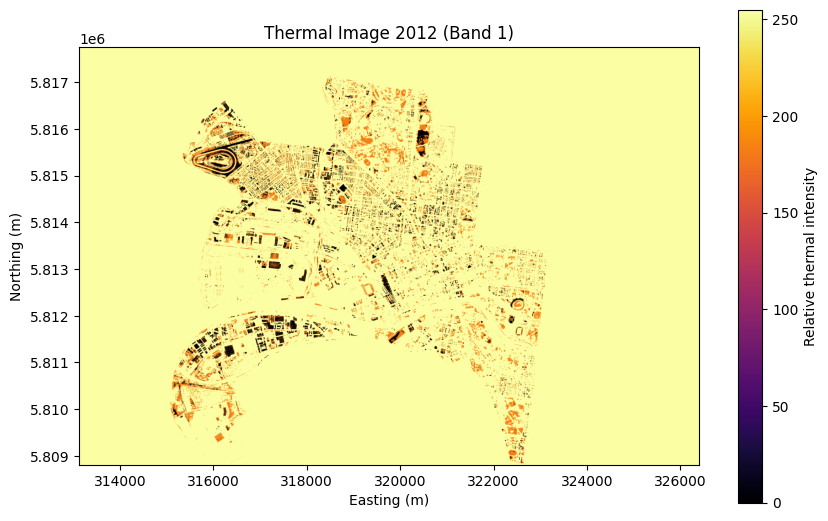

Interpretation: Brighter colours indicate relatively hotter surface zones within the raster extent.


In [16]:
# Plot thermal intensity with a labelled colour scale.
thermal_band_1 = thermal_src.read(1)
fig, ax = plt.subplots(figsize=(10, 8))
thermal_img = ax.imshow(
    thermal_band_1,
    cmap="inferno",
    extent=(thermal_src.bounds.left, thermal_src.bounds.right, thermal_src.bounds.bottom, thermal_src.bounds.top),
    origin="upper"
)
cbar = plt.colorbar(thermal_img, ax=ax, shrink=0.8)
cbar.set_label("Relative thermal intensity")
ax.set_title("Thermal Image 2012 (Band 1)")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
plt.show()

print("Interpretation: Brighter colours indicate relatively hotter surface zones within the raster extent.")


# 11. Reprojecting the Tree Canopy Dataset

In [17]:
# Reproject the canopy dataset to match the thermal image CRS.
canopy_projected = canopy_gdf.to_crs(thermal_src.crs)

print("Original canopy CRS:", canopy_gdf.crs)
print("Projected canopy CRS:", canopy_projected.crs)

Original canopy CRS: EPSG:4326
Projected canopy CRS: PROJCS["GDA94 / MGA zone 55",GEOGCS["GDA94",DATUM["Geocentric_Datum_of_Australia_1994",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6283"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4283"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",147],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","28355"]]


In [18]:
# Check the projected canopy bounds.
print("Projected canopy bounds:", canopy_projected.total_bounds)
print("Thermal bounds:", thermal_src.bounds)

Projected canopy bounds: [ 315081.687  5808789.095   323212.6733 5817147.842 ]
Thermal bounds: BoundingBox(left=313125.50287426636, bottom=5808810.7843015315, right=326397.0294173194, top=5817743.135499577)


# 12. Visualising the Reprojected Tree Canopy Dataset

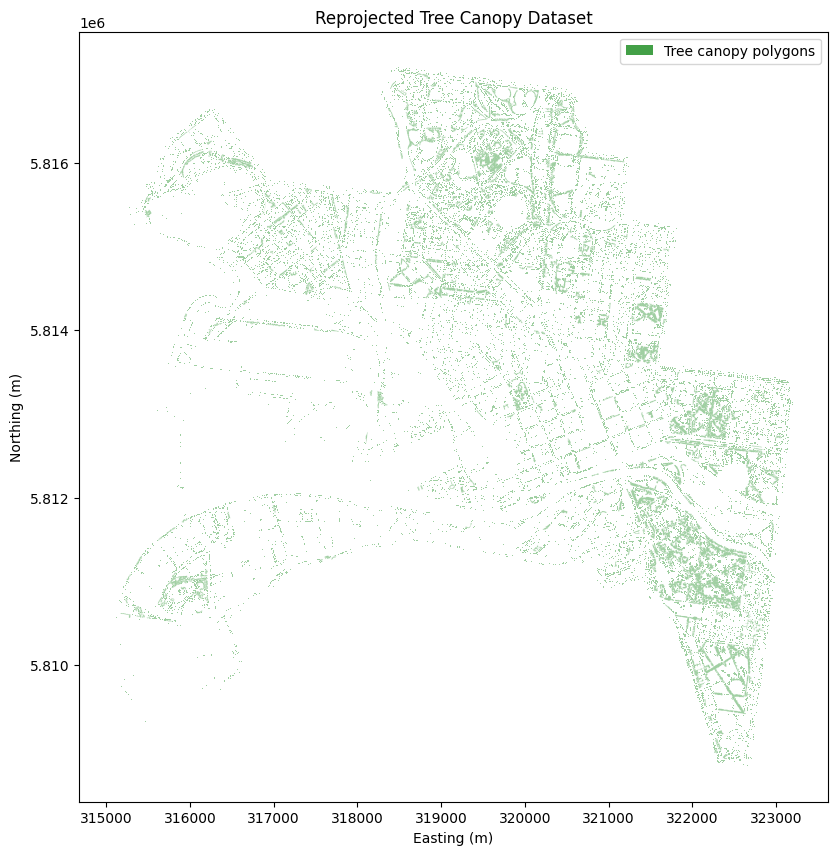

Interpretation: The canopy layer now shares the thermal CRS, so direct spatial overlay is valid.


In [19]:
# Plot the reprojected canopy dataset.
fig, ax = plt.subplots(figsize=(10, 10))
canopy_projected.plot(ax=ax, color="#43a047", edgecolor="none", alpha=0.5)
ax.set_title("Reprojected Tree Canopy Dataset")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.legend(
    handles=[Patch(facecolor="#43a047", edgecolor="none", label="Tree canopy polygons")],
    loc="upper right"
)
plt.show()

print("Interpretation: The canopy layer now shares the thermal CRS, so direct spatial overlay is valid.")


# 13. Creating a Visual Overlay

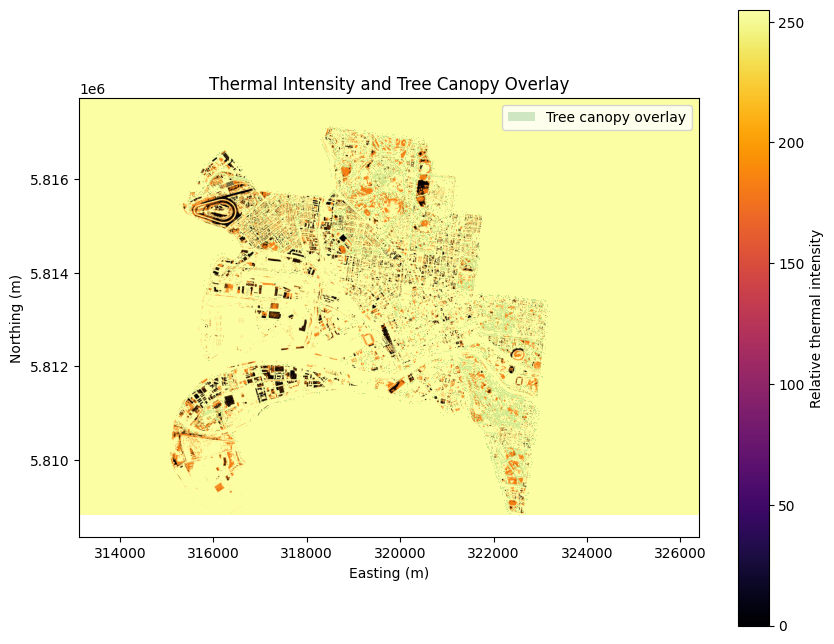

Interpretation: Thermal hotspots are more concerning where canopy overlay is sparse.


In [20]:
# Overlay the reprojected canopy dataset on top of thermal intensity.
thermal_band_1 = thermal_src.read(1)
fig, ax = plt.subplots(figsize=(10, 10))
thermal_overlay = ax.imshow(
    thermal_band_1,
    cmap="inferno",
    extent=(thermal_src.bounds.left, thermal_src.bounds.right, thermal_src.bounds.bottom, thermal_src.bounds.top),
    origin="upper"
)
canopy_projected.plot(ax=ax, color="#43a047", edgecolor="none", alpha=0.25)
cbar = plt.colorbar(thermal_overlay, ax=ax, shrink=0.8)
cbar.set_label("Relative thermal intensity")
ax.set_title("Thermal Intensity and Tree Canopy Overlay")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.legend(
    handles=[Patch(facecolor="#43a047", edgecolor="none", alpha=0.25, label="Tree canopy overlay")],
    loc="upper right"
)
plt.show()

print("Interpretation: Thermal hotspots are more concerning where canopy overlay is sparse.")


# 14. Comparing the Spatial Extent

In [21]:
# Compare the bounds of the reprojected canopy dataset and the thermal image.
print("Reprojected canopy bounds:", canopy_projected.total_bounds)
print("Thermal bounds:", thermal_src.bounds)

Reprojected canopy bounds: [ 315081.687  5808789.095   323212.6733 5817147.842 ]
Thermal bounds: BoundingBox(left=313125.50287426636, bottom=5808810.7843015315, right=326397.0294173194, top=5817743.135499577)


# 15. Calculating Tree Canopy Area

In [22]:
# Calculate the area of each canopy geometry.
canopy_projected["canopy_area_m2"] = canopy_projected.geometry.area

print(canopy_projected["canopy_area_m2"].head())

0    1501.469496
1      23.904648
2      14.227728
3       0.633600
4       5.644800
Name: canopy_area_m2, dtype: float64


In [23]:
# Display summary statistics for canopy area.
print(canopy_projected["canopy_area_m2"].describe())

count    57980.000000
mean        76.295950
std        676.024400
min          0.057600
25%          2.073600
50%         11.577600
75%         47.174400
max      90337.933129
Name: canopy_area_m2, dtype: float64


# 16. Exploring Tree Canopy Area Distribution

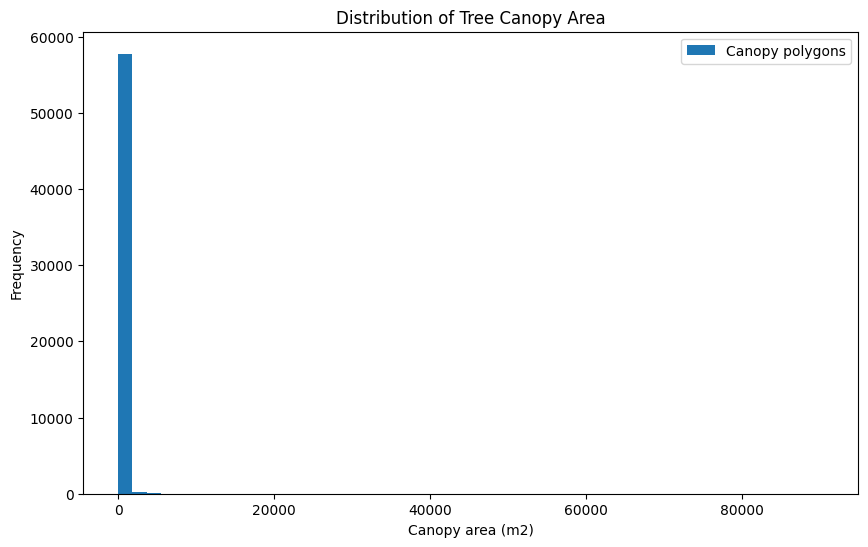

Interpretation: The canopy area distribution is right-skewed, with many small polygons and fewer large polygons.


In [24]:
# Plot a histogram of canopy area.
plt.figure(figsize=(10, 6))
plt.hist(canopy_projected["canopy_area_m2"], bins=50, label="Canopy polygons")
plt.title("Distribution of Tree Canopy Area")
plt.xlabel("Canopy area (m2)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

print("Interpretation: The canopy area distribution is right-skewed, with many small polygons and fewer large polygons.")


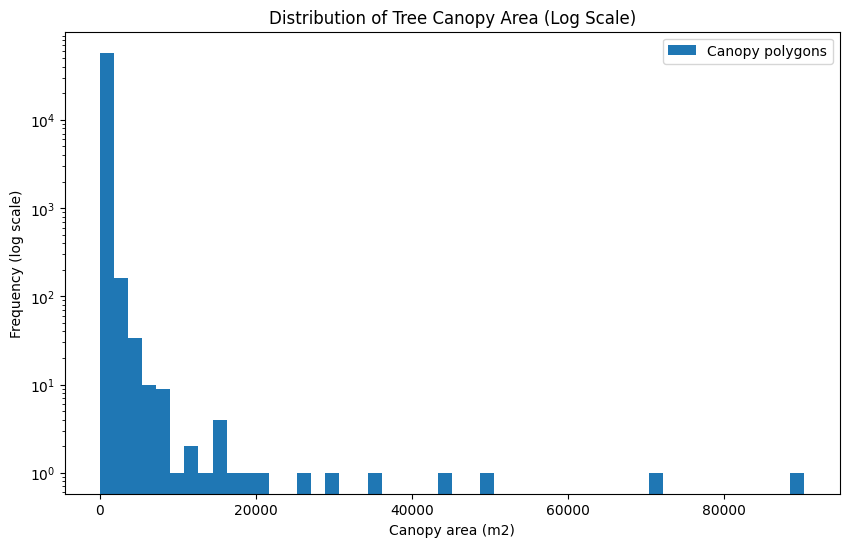

Interpretation: The log view confirms strong imbalance and supports percentile-based canopy thresholds.


In [25]:
# Plot the distribution on a log scale.
plt.figure(figsize=(10, 6))
plt.hist(canopy_projected["canopy_area_m2"], bins=50, log=True, label="Canopy polygons")
plt.title("Distribution of Tree Canopy Area (Log Scale)")
plt.xlabel("Canopy area (m2)")
plt.ylabel("Frequency (log scale)")
plt.legend()
plt.show()

print("Interpretation: The log view confirms strong imbalance and supports percentile-based canopy thresholds.")


# 17. Creating an Analysis Grid

Transition: The canopy polygons are now cleaned and aligned to the thermal CRS. The next step is to create a consistent spatial unit for comparison.

Objective: Build a fixed-size grid so each cell can store both canopy and thermal indicators for hotspot analysis.

In [26]:
# Create a grid based on the thermal image bounds.
minx, miny, maxx, maxy = thermal_src.bounds

cell_size = 250  # in metres

grid_cells = []
x = minx
while x < maxx:
    y = miny
    while y < maxy:
        grid_cells.append(box(x, y, x + cell_size, y + cell_size))
        y += cell_size
    x += cell_size

grid_gdf = gpd.GeoDataFrame({"geometry": grid_cells}, crs=thermal_src.crs)

print("Grid created successfully.")
print("Number of grid cells:", len(grid_gdf))

Grid created successfully.
Number of grid cells: 1944


In [27]:
# Display the first 5 grid cells.
grid_gdf.head()

,geometry
0,"POLYGON ((313375.503 5808810.784, 313375.503 5..."
1,"POLYGON ((313375.503 5809060.784, 313375.503 5..."
2,"POLYGON ((313375.503 5809310.784, 313375.503 5..."
3,"POLYGON ((313375.503 5809560.784, 313375.503 5..."
4,"POLYGON ((313375.503 5809810.784, 313375.503 5..."


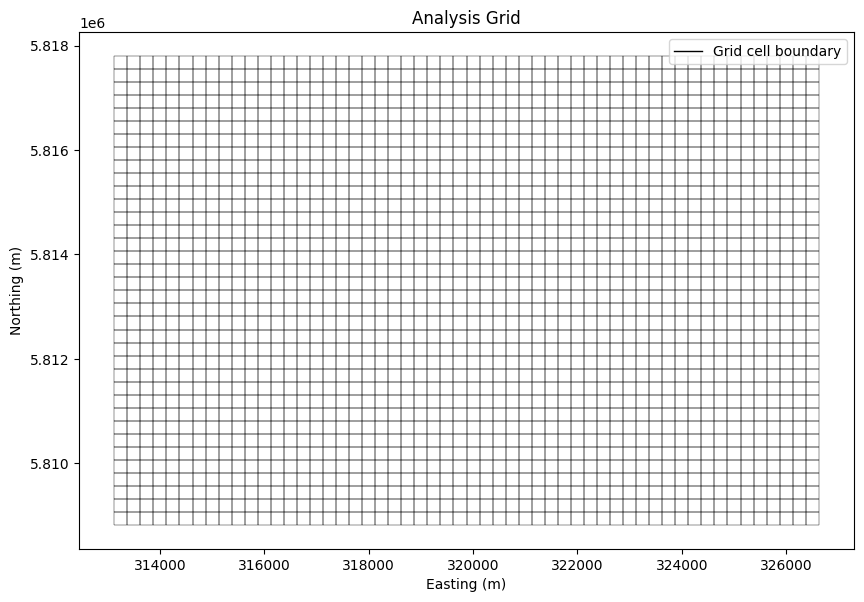

Interpretation: The grid defines a consistent spatial unit for comparing canopy and thermal indicators.


In [28]:
# Plot the analysis grid.
fig, ax = plt.subplots(figsize=(10, 10))
grid_gdf.boundary.plot(ax=ax, linewidth=0.3, color="black")
ax.set_title("Analysis Grid")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.legend(
    handles=[Line2D([0], [0], color="black", linewidth=1, label="Grid cell boundary")],
    loc="upper right"
)
plt.show()

print("Interpretation: The grid defines a consistent spatial unit for comparing canopy and thermal indicators.")


# 18. Calculating Grid Cell Area

In [29]:
# Calculate the area of each grid cell.
grid_gdf["grid_area_m2"] = grid_gdf.geometry.area

print(grid_gdf["grid_area_m2"].head())

0    62500.0
1    62500.0
2    62500.0
3    62500.0
4    62500.0
Name: grid_area_m2, dtype: float64


In [30]:
# Display summary statistics for grid cell area.
print(grid_gdf["grid_area_m2"].describe())

count     1944.0
mean     62500.0
std          0.0
min      62500.0
25%      62500.0
50%      62500.0
75%      62500.0
max      62500.0
Name: grid_area_m2, dtype: float64


# 19. Intersecting Tree Canopy with the Grid

In [31]:
# Intersect the reprojected canopy dataset with the analysis grid.
canopy_grid_intersection = gpd.overlay(canopy_projected, grid_gdf, how="intersection")

print("Intersection created successfully.")
print("Intersection shape:", canopy_grid_intersection.shape)    

Intersection created successfully.
Intersection shape: (61584, 4)


In [32]:
# Display the first 5 rows of the intersection result.
canopy_grid_intersection.head()

,geo_point_2d,canopy_area_m2,grid_area_m2,geometry
0,"{'lon': 144.98303001088595, 'lat': -37.8298681...",1501.469496,62500.0,"POLYGON ((322522.191 5811167.023, 322522.191 5..."
1,"{'lon': 144.97144661356745, 'lat': -37.8298745...",23.904648,62500.0,"POLYGON ((321479.388 5811126.223, 321479.388 5..."
2,"{'lon': 144.98646678135142, 'lat': -37.8302139...",14.227728,62500.0,"POLYGON ((322802.992 5811115.663, 322802.992 5..."
3,"{'lon': 144.9011718210025, 'lat': -37.82874224...",0.633600,62500.0,"POLYGON ((315290.728 5811111.102, 315290.728 5..."
4,"{'lon': 144.96518349051888, 'lat': -37.8299209...",5.644800,62500.0,"POLYGON ((320928.106 5811105.822, 320928.106 5..."


# 20. Calculating Canopy Area within Each Grid Cell

In [33]:
# Calculate the area of each intersected canopy piece.
canopy_grid_intersection["intersection_area_m2"] = canopy_grid_intersection.geometry.area

print(canopy_grid_intersection["intersection_area_m2"].head())

0    1501.469496
1      23.904648
2      14.227728
3       0.633600
4       5.644800
Name: intersection_area_m2, dtype: float64


In [34]:
# Display summary statistics for intersection area.
print(canopy_grid_intersection["intersection_area_m2"].describe())

count    61584.000000
mean        71.828890
std        400.162206
min          0.000623
25%          2.073600
50%         11.462448
75%         46.519906
max      27773.823698
Name: intersection_area_m2, dtype: float64


# 21. Summarising Canopy Area by Grid Cell

In [35]:
# Reset the grid index so each cell has a unique ID.
grid_gdf = grid_gdf.reset_index().rename(columns={"index": "grid_id"})
print(grid_gdf.head())

   grid_id                                           geometry  grid_area_m2
0        0  POLYGON ((313375.503 5808810.784, 313375.503 5...       62500.0
1        1  POLYGON ((313375.503 5809060.784, 313375.503 5...       62500.0
2        2  POLYGON ((313375.503 5809310.784, 313375.503 5...       62500.0
3        3  POLYGON ((313375.503 5809560.784, 313375.503 5...       62500.0
4        4  POLYGON ((313375.503 5809810.784, 313375.503 5...       62500.0


In [36]:
# Re-run the intersection using the grid with grid_id.
canopy_grid_intersection = gpd.overlay(canopy_projected, grid_gdf, how="intersection")

# Calculate the intersected canopy area again.
canopy_grid_intersection["intersection_area_m2"] = canopy_grid_intersection.geometry.area

print("Intersection recreated successfully.")
print(canopy_grid_intersection.head())

Intersection recreated successfully.
                                        geo_point_2d  canopy_area_m2  grid_id  \
0  {'lon': 144.98303001088595, 'lat': -37.8298681...     1501.469496     1341   
1  {'lon': 144.97144661356745, 'lat': -37.8298745...       23.904648     1197   
2  {'lon': 144.98646678135142, 'lat': -37.8302139...       14.227728     1377   
3  {'lon': 144.9011718210025, 'lat': -37.82874224...        0.633600      297   
4  {'lon': 144.96518349051888, 'lat': -37.8299209...        5.644800     1125   

   grid_area_m2                                           geometry  \
0       62500.0  POLYGON ((322522.191 5811167.023, 322522.191 5...   
1       62500.0  POLYGON ((321479.388 5811126.223, 321479.388 5...   
2       62500.0  POLYGON ((322802.992 5811115.663, 322802.992 5...   
3       62500.0  POLYGON ((315290.728 5811111.102, 315290.728 5...   
4       62500.0  POLYGON ((320928.106 5811105.822, 320928.106 5...   

   intersection_area_m2  
0           1501.469496  
1  

In [37]:
# Sum canopy area within each grid cell.
canopy_by_grid = canopy_grid_intersection.groupby("grid_id")["intersection_area_m2"].sum().reset_index()

print(canopy_by_grid.head())

   grid_id  intersection_area_m2
0      256            101.491656
1      257             88.474344
2      258             15.335252
3      259             12.479530
4      290              0.988994


# 22. Calculating Canopy Cover Percentage

Transition: After intersecting canopy geometry with the grid, we convert raw intersected area into a percentage to make cells directly comparable.

Objective: Express canopy coverage as `canopy_cover_pct` per grid cell for fair hotspot rule application.

In [38]:
# Merge the canopy totals back into the grid.
grid_gdf = grid_gdf.merge(canopy_by_grid, on="grid_id", how="left")

# Fill missing canopy values with 0.
grid_gdf["intersection_area_m2"] = grid_gdf["intersection_area_m2"].fillna(0)

# Calculate canopy cover percentage.
grid_gdf["canopy_cover_pct"] = (grid_gdf["intersection_area_m2"] / grid_gdf["grid_area_m2"]) * 100

print(grid_gdf[["grid_id", "grid_area_m2", "intersection_area_m2", "canopy_cover_pct"]].head())

   grid_id  grid_area_m2  intersection_area_m2  canopy_cover_pct
0        0       62500.0                   0.0               0.0
1        1       62500.0                   0.0               0.0
2        2       62500.0                   0.0               0.0
3        3       62500.0                   0.0               0.0
4        4       62500.0                   0.0               0.0


In [39]:
# Summary statistics for canopy cover percentage.
print(grid_gdf["canopy_cover_pct"].describe())

count    1944.000000
mean        3.640749
std         7.838087
min         0.000000
25%         0.000000
50%         0.000000
75%         3.080734
max        52.760906
Name: canopy_cover_pct, dtype: float64


# 23. Calculating Thermal Intensity for Each Grid Cell

Transition: With canopy percentage prepared, we now compute the thermal indicator for the same grid cells.

Objective: Calculate `mean_thermal` per cell so hotspot logic can combine heat intensity and canopy scarcity.

In [40]:
# Calculate one thermal value for each grid cell.
thermal_means = []
no_usable_thermal_cells = 0

for geom in grid_gdf.geometry:
    try:
        # Read band 1 only so the metric is consistent across all cells.
        out_image, _ = mask(thermal_src, [geom], crop=True)
        data = out_image[0].astype(float)

        # Treat only background value (0) as missing.
        data[data <= 0] = np.nan

        if np.isnan(data).all():
            thermal_means.append(np.nan)
            no_usable_thermal_cells += 1
        else:
            thermal_means.append(np.nanmean(data))
    except Exception:
        thermal_means.append(np.nan)
        no_usable_thermal_cells += 1

grid_gdf["mean_thermal"] = thermal_means

print(grid_gdf["mean_thermal"].head())
print("Cells with no usable thermal pixels:", no_usable_thermal_cells)

0    255.0
1    255.0
2    255.0
3    255.0
4    255.0
Name: mean_thermal, dtype: float64
Cells with no usable thermal pixels: 0


In [41]:
# Summary statistics for mean thermal values.
print(grid_gdf["mean_thermal"].describe())

count    1944.000000
mean      252.130529
std         5.799883
min       207.424201
25%       251.574189
50%       255.000000
75%       255.000000
max       255.000000
Name: mean_thermal, dtype: float64


# 24. Exploring Thermal Intensity Distribution

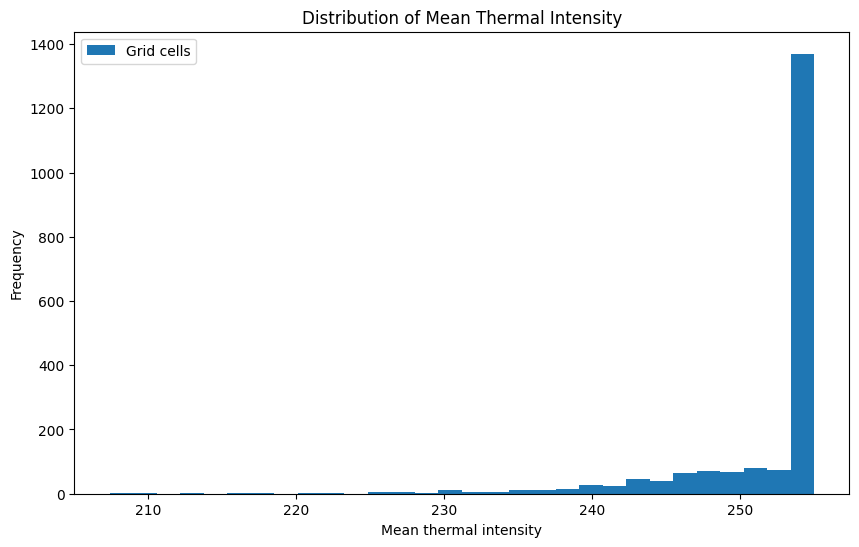

Interpretation: Thermal intensity varies across the grid, enabling percentile-based hotspot classification.


In [42]:
# Plot the distribution of mean thermal intensity.
plt.figure(figsize=(10, 6))
plt.hist(grid_gdf["mean_thermal"], bins=30, label="Grid cells")
plt.title("Distribution of Mean Thermal Intensity")
plt.xlabel("Mean thermal intensity")
plt.ylabel("Frequency")
plt.legend()
plt.show()

print("Interpretation: Thermal intensity varies across the grid, enabling percentile-based hotspot classification.")


In [43]:
# Display the first 10 rows of thermal and canopy indicators together.
print(grid_gdf[["grid_id", "canopy_cover_pct", "mean_thermal"]].head(10))

   grid_id  canopy_cover_pct  mean_thermal
0        0               0.0         255.0
1        1               0.0         255.0
2        2               0.0         255.0
3        3               0.0         255.0
4        4               0.0         255.0
5        5               0.0         255.0
6        6               0.0         255.0
7        7               0.0         255.0
8        8               0.0         255.0
9        9               0.0         255.0


# 25. Identifying High Thermal and Low Canopy Cells

Transition: We now have both core indicators (`canopy_cover_pct` and `mean_thermal`) at cell level.

Objective: Apply transparent rule-based thresholds to classify initial hotspot priority cells aligned with the project goal.

In [44]:
# Define thresholds for hotspot rules.
thermal_max = grid_gdf["mean_thermal"].max()
quantile_candidates = [0.75, 0.70, 0.65, 0.60, 0.55, 0.50, 0.45, 0.40]
selected_quantile = None
thermal_threshold = np.nan

for q in quantile_candidates:
    candidate_threshold = grid_gdf["mean_thermal"].quantile(q)
    if candidate_threshold < thermal_max:
        thermal_threshold = candidate_threshold
        selected_quantile = q
        break

if selected_quantile is None:
    selected_quantile = 0.25
    thermal_threshold = grid_gdf["mean_thermal"].quantile(selected_quantile)

canopy_threshold = 5.0

print("Thermal max:", thermal_max)
print("Chosen thermal quantile:", selected_quantile)
print("Chosen thermal threshold:", thermal_threshold)
print("Canopy threshold:", canopy_threshold)
print("Note: Many cells share the max value, so the next step uses a top-25% ranking rule for high thermal selection.")

Thermal max: 255.0
Chosen thermal quantile: 0.25
Chosen thermal threshold: 251.5741891939582
Canopy threshold: 5.0
Note: Many cells share the max value, so the next step uses a top-25% ranking rule for high thermal selection.


In [45]:
# Create classification columns.
valid_thermal = grid_gdf[["mean_thermal", "canopy_cover_pct"]].dropna(subset=["mean_thermal"]).sort_values(
    ["mean_thermal", "canopy_cover_pct"],
    ascending=[False, True]
)
top_thermal_count = int(np.ceil(len(valid_thermal) * 0.25))
high_thermal_index = valid_thermal.index[:top_thermal_count]

grid_gdf["high_thermal"] = False
grid_gdf.loc[high_thermal_index, "high_thermal"] = True
grid_gdf["low_canopy"] = grid_gdf["canopy_cover_pct"] < canopy_threshold

# Final priority cells.
grid_gdf["priority_cell"] = grid_gdf["high_thermal"] & grid_gdf["low_canopy"]

print("Cells in top 25% thermal group:", top_thermal_count)
print(grid_gdf[["high_thermal", "low_canopy", "priority_cell"]].sum())

Cells in top 25% thermal group: 486
high_thermal      486
low_canopy       1527
priority_cell     486
dtype: int64


# 26. Visualising Priority Cells

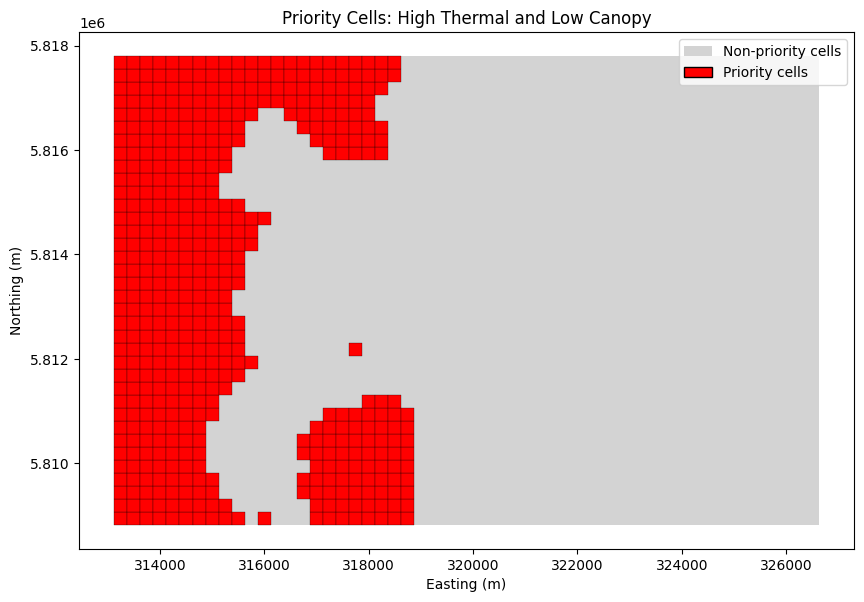

Interpretation: Priority cells capture areas where low canopy and high thermal intensity coincide.


In [46]:
# Plot priority cells.
fig, ax = plt.subplots(figsize=(10, 10))

grid_gdf.plot(
    ax=ax,
    color="lightgrey",
    edgecolor="none"
)

grid_gdf[grid_gdf["priority_cell"]].plot(
    ax=ax,
    color="red",
    edgecolor="black",
    linewidth=0.2
)

ax.set_title("Priority Cells: High Thermal and Low Canopy")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.legend(
    handles=[
        Patch(facecolor="lightgrey", edgecolor="none", label="Non-priority cells"),
        Patch(facecolor="red", edgecolor="black", label="Priority cells")
    ],
    loc="upper right"
)
plt.show()

print("Interpretation: Priority cells capture areas where low canopy and high thermal intensity coincide.")


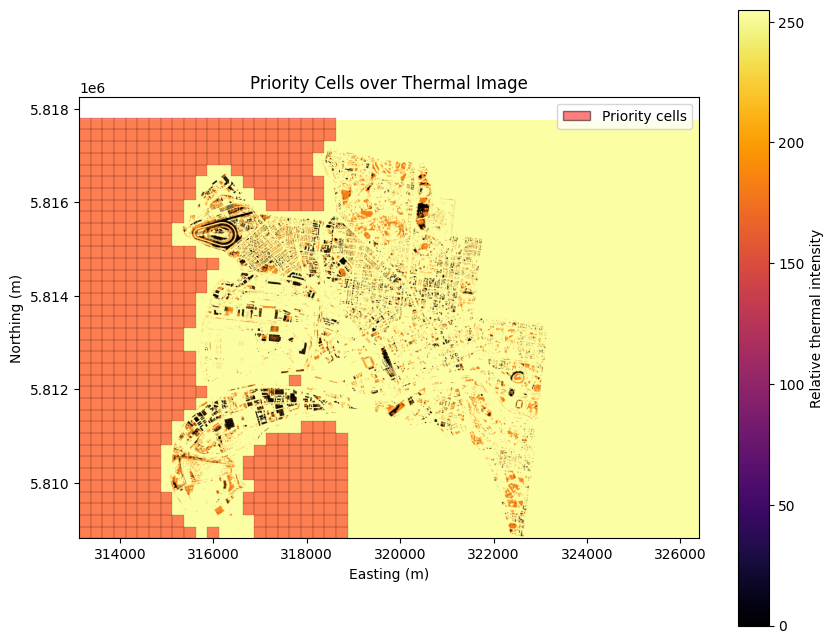

Interpretation: Priority cells align with the warmer portions of the thermal raster.


In [47]:
# Overlay priority cells on the thermal image.
thermal_band_1 = thermal_src.read(1)
fig, ax = plt.subplots(figsize=(10, 10))
thermal_priority = ax.imshow(
    thermal_band_1,
    cmap="inferno",
    extent=(thermal_src.bounds.left, thermal_src.bounds.right, thermal_src.bounds.bottom, thermal_src.bounds.top),
    origin="upper"
)

grid_gdf[grid_gdf["priority_cell"]].plot(
    ax=ax,
    color="red",
    edgecolor="black",
    linewidth=0.2,
    alpha=0.5
)

cbar = plt.colorbar(thermal_priority, ax=ax, shrink=0.8)
cbar.set_label("Relative thermal intensity")
ax.set_title("Priority Cells over Thermal Image")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.legend(
    handles=[Patch(facecolor="red", edgecolor="black", alpha=0.5, label="Priority cells")],
    loc="upper right"
)
plt.show()

print("Interpretation: Priority cells align with the warmer portions of the thermal raster.")


# 27. Summarising Hotspot Results


In [48]:
# Summary of hotspot results.
total_cells = len(grid_gdf)
priority_cells = grid_gdf["priority_cell"].sum()
priority_pct = (priority_cells / total_cells) * 100

mean_canopy_priority = grid_gdf.loc[grid_gdf["priority_cell"], "canopy_cover_pct"].mean()
mean_thermal_priority = grid_gdf.loc[grid_gdf["priority_cell"], "mean_thermal"].mean()

print("Total grid cells:", total_cells)
print("Priority cells:", priority_cells)
print("Priority cell percentage:", priority_pct)
print("Mean canopy cover in priority cells:", mean_canopy_priority)
print("Mean thermal intensity in priority cells:", mean_thermal_priority)

Total grid cells: 1944
Priority cells: 486
Priority cell percentage: 25.0
Mean canopy cover in priority cells: 0.0
Mean thermal intensity in priority cells: 255.0


# 28. Ranking Priority Cells

In [49]:
# Create a simple hotspot score.
grid_gdf["hotspot_score"] = grid_gdf["mean_thermal"] * (100 - grid_gdf["canopy_cover_pct"]) / 100

# Show top 10 cells by score.
top_hotspots = grid_gdf.sort_values("hotspot_score", ascending=False)[
    ["grid_id", "mean_thermal", "canopy_cover_pct", "hotspot_score", "priority_cell"]
].head(10)

print(top_hotspots)

      grid_id  mean_thermal  canopy_cover_pct  hotspot_score  priority_cell
1943     1943         255.0               0.0          255.0          False
0           0         255.0               0.0          255.0           True
1           1         255.0               0.0          255.0           True
2           2         255.0               0.0          255.0           True
3           3         255.0               0.0          255.0           True
4           4         255.0               0.0          255.0           True
5           5         255.0               0.0          255.0           True
6           6         255.0               0.0          255.0           True
1927     1927         255.0               0.0          255.0          False
1926     1926         255.0               0.0          255.0          False


# 29. Hotspot Interpretation

The hotspot identification step now uses a top-25% thermal ranking rule (with canopy as a tie-breaker) together with a low-canopy threshold. This keeps the classification stable when many cells share the same maximum thermal value.

Under this setup, 25% of grid cells were selected as high thermal, and these cells also showed extremely low canopy cover. The average canopy cover in priority cells is close to zero, while thermal intensity remains at the upper end of the raster range.

These findings support the project goal by highlighting locations where low vegetation cover and high thermal intensity overlap. Because the thermal raster is relative image intensity rather than direct physical temperature, the hotspot output should be interpreted as relative heat priority, not exact temperature.

In future work, the hotspot identification could be refined by testing alternative thermal thresholds, different grid sizes, or more advanced hotspot scoring methods.

# 30. Building a Hotspot Clustering Model

Transition: Rule-based hotspot flags provide an initial map. Clustering adds a data-driven view of how cell patterns naturally group.

Objective: Build an initial unsupervised model that groups cells by combined thermal and canopy characteristics.

This section builds an unsupervised clustering model to group grid cells based on their thermal intensity and tree canopy cover.

The aim is to identify whether the study area naturally separates into different hotspot-related patterns, such as high thermal intensity with low canopy cover, or lower thermal intensity with higher canopy presence.

In [50]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 31. Preparing Features for Clustering

Objective: Use the two project indicators (`mean_thermal`, `canopy_cover_pct`) as clustering features and standardise them to the same scale.

In [51]:
# Select features for clustering.
clustering_data = grid_gdf[["mean_thermal", "canopy_cover_pct"]].copy()

# Fill missing values with median so KMeans can run safely.
missing_before = clustering_data.isna().sum()
clustering_data["mean_thermal"] = clustering_data["mean_thermal"].fillna(clustering_data["mean_thermal"].median())
clustering_data["canopy_cover_pct"] = clustering_data["canopy_cover_pct"].fillna(clustering_data["canopy_cover_pct"].median())
missing_after = clustering_data.isna().sum()

print("Missing values before fill:")
print(missing_before)
print("Missing values after fill:")
print(missing_after)
print(clustering_data.head())

Missing values before fill:
mean_thermal        0
canopy_cover_pct    0
dtype: int64
Missing values after fill:
mean_thermal        0
canopy_cover_pct    0
dtype: int64
   mean_thermal  canopy_cover_pct
0         255.0               0.0
1         255.0               0.0
2         255.0               0.0
3         255.0               0.0
4         255.0               0.0


In [52]:
# Standardise the features before clustering.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(clustering_data)

print("Scaled feature matrix shape:", X_scaled.shape)

Scaled feature matrix shape: (1944, 2)


# 32. Training the KMeans Model

Objective: Compare multiple `k` values and justify the selected cluster count using silhouette score (plus inertia for context).

In [53]:
# Compare candidate k values before final model selection.
k_candidates = [3, 4, 5, 6]
comparison_rows = []

for k in k_candidates:
    candidate_model = KMeans(n_clusters=k, random_state=42, n_init=10)
    candidate_labels = candidate_model.fit_predict(X_scaled)
    comparison_rows.append({
        "k": k,
        "inertia": candidate_model.inertia_,
        "silhouette_score": silhouette_score(X_scaled, candidate_labels)
    })

kmeans_comparison = pd.DataFrame(comparison_rows).sort_values("k").reset_index(drop=True)
print("k comparison table:")
print(kmeans_comparison)

best_k = int(kmeans_comparison.loc[kmeans_comparison["silhouette_score"].idxmax(), "k"])
print("Selected k based on silhouette score:", best_k)

# Train final KMeans model using justified k.
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
grid_gdf["cluster"] = kmeans.fit_predict(X_scaled)

print(grid_gdf["cluster"].value_counts().sort_index())

k comparison table:
   k      inertia  silhouette_score
0  3  1018.179138          0.770642
1  4   636.990210          0.782058
2  5   510.387131          0.773753
3  6   424.799515          0.780504
Selected k based on silhouette score: 4
cluster
0    1443
1      63
2     125
3     313
Name: count, dtype: int64


# 33. Inspecting Cluster Profiles

Objective: Interpret each cluster in terms of mean thermal intensity and canopy coverage, then relate patterns back to hotspot planning priorities.

In [54]:
# Examine the mean feature values for each cluster.
cluster_summary = grid_gdf.groupby("cluster")[["mean_thermal", "canopy_cover_pct"]].mean()

print(cluster_summary)

         mean_thermal  canopy_cover_pct
cluster                                
0          254.797077          0.238941
1          230.036567          8.684847
2          245.789995         27.852616
3          246.816334          8.639306


In [55]:
# Count the number of cells in each cluster.
cluster_counts = grid_gdf["cluster"].value_counts().sort_index()
print(cluster_counts)

cluster
0    1443
1      63
2     125
3     313
Name: count, dtype: int64


# 34. Visualising Cluster Results

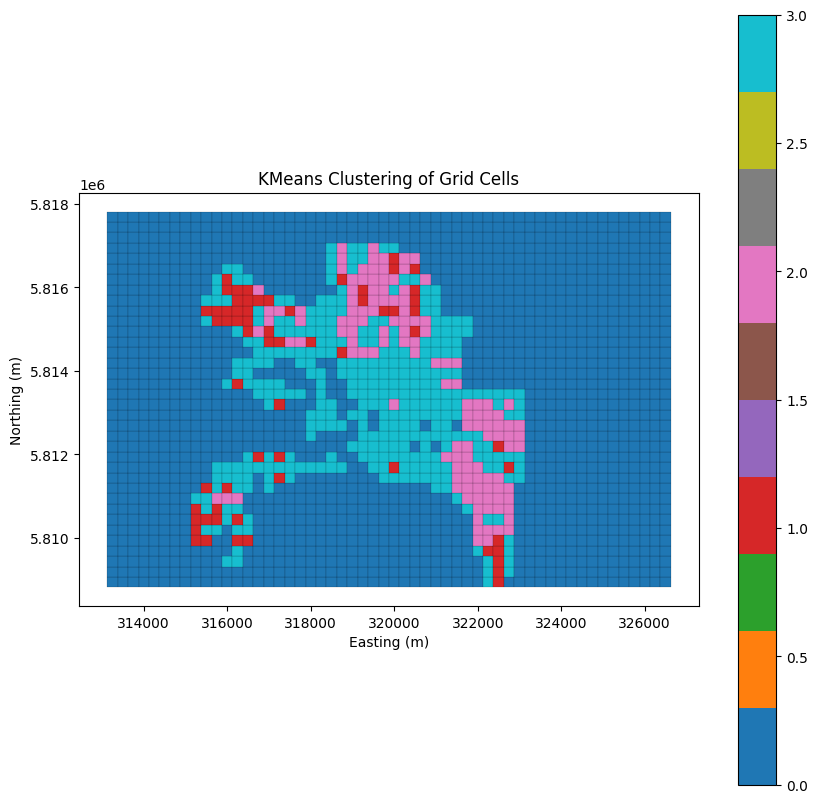

Interpretation: Clusters separate grid cells into distinct canopy-thermal profiles for planning comparison.


In [56]:
# Plot the clustering result.
fig, ax = plt.subplots(figsize=(10, 10))

grid_gdf.plot(
    column="cluster",
    ax=ax,
    legend=True,
    cmap="tab10",
    edgecolor="black",
    linewidth=0.1
)

ax.set_title("KMeans Clustering of Grid Cells")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
plt.show()

print("Interpretation: Clusters separate grid cells into distinct canopy-thermal profiles for planning comparison.")


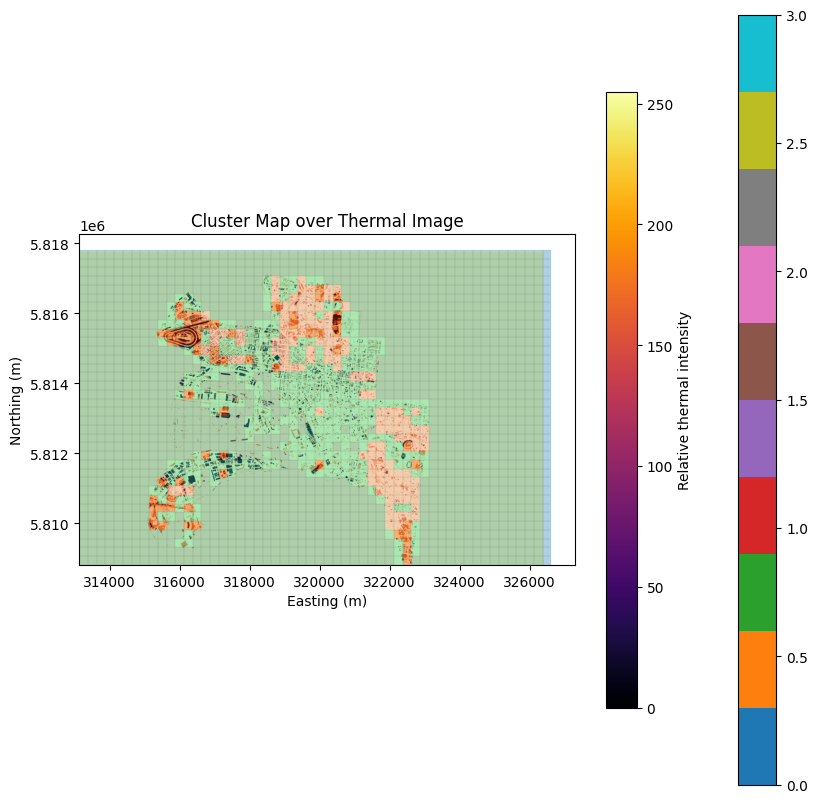

Interpretation: Cluster boundaries show how canopy-thermal combinations are spatially distributed across the study area.


In [57]:
# Overlay cluster results on the thermal image.
thermal_band_1 = thermal_src.read(1)
fig, ax = plt.subplots(figsize=(10, 10))
thermal_cluster = ax.imshow(
    thermal_band_1,
    cmap="inferno",
    extent=(thermal_src.bounds.left, thermal_src.bounds.right, thermal_src.bounds.bottom, thermal_src.bounds.top),
    origin="upper"
)

grid_gdf.plot(
    column="cluster",
    ax=ax,
    legend=True,
    cmap="tab10",
    alpha=0.35,
    edgecolor="black",
    linewidth=0.1
)

cbar = plt.colorbar(thermal_cluster, ax=ax, shrink=0.8)
cbar.set_label("Relative thermal intensity")
ax.set_title("Cluster Map over Thermal Image")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
plt.show()

print("Interpretation: Cluster boundaries show how canopy-thermal combinations are spatially distributed across the study area.")
